# 1.2 — Reddit: Network Analysis

Drie types netwerken:
1. **User-user reply network** — wie antwoordt op wie?
2. **Author activity (cross-subreddit)** — which authors are active in multiple subreddits?
3. **Post-comment bipartite network** — welke posts genereren de meeste engagement?

<!-- toc -->
## Contents
- [1. User-user Reply Network](#1-user-user-reply-network)
- [2. Author Activity — Cross-subreddit Overlap](#2-author-activity-cross-subreddit-overlap)
- [3. Post-Comment Bipartite Network — Engagement](#3-post-comment-bipartite-network-engagement)


In [1]:
import sys
sys.path.insert(0, '..')
from house_style import apply_style, styled_fig, style_ax, BG_DARK, BG_PANEL
from house_style import REPUBLICAN, DEMOCRAT, NEUTRAL, TEXT_PRIMARY, TEXT_MUTED
apply_style()

import json
from pathlib import Path
from collections import defaultdict, Counter

import pandas as pd
import numpy as np
import networkx as nx
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches

DATA_DIR = Path('../../Data/1_Bronze/Reddit')

SUBREDDIT_COLORS = {
    'conservative': REPUBLICAN,
    'trump':        '#c0392b',
    'republican':   '#e07b39',
    'democrats':    DEMOCRAT,
    'liberal':      '#5dade2',
    'worldnews':    '#2ecc71',
    'politics':     '#f39c12',
}

In [2]:
# Load clean comments parquet
df = pd.read_parquet(DATA_DIR / 'reddit_comments_raw.parquet')
df_posts = pd.read_parquet(DATA_DIR / 'reddit_posts_raw.parquet')

print(f'Comments: {df.shape}')
print(df['subreddit'].value_counts())
print(f'\nPosts: {df_posts.shape}')
print(df_posts['subreddit'].value_counts())

Comments: (4094357, 18)
subreddit
politics        1868477
worldnews       1498387
democrats        326938
conservative     302333
republican        98222
Name: count, dtype: int64

Posts: (188474, 17)
subreddit
politics        69963
conservative    41790
worldnews       36854
democrats       20756
republican      19111
Name: count, dtype: int64


---
## 1. User-user Reply Network

An edge goes from author A to author B when A posts a comment in reply to a comment by B.  
`parent_id` starting with `t1_` = reply to comment; `t3_` = reply to post (excluded).

In [3]:
# Build lookup: comment_id → author
id_to_author = dict(zip(df['id'], df['author']))
print(f'Lookup built: {len(id_to_author):,} comments')

Lookup gebouwd: 4,094,357 comments


In [4]:
def build_reply_network(df_sub, id_to_author, top_n_authors=300, min_edge_weight=2):
    """Build a weighted directed network of author replies.
    
    Only comment-on-comment replies (parent_id starts with t1_).
    Filter to top_n most active authors to keep the graph manageable.
    """
    # Keep only comment-on-comment replies
    replies = df_sub[df_sub['parent_id'].str.startswith('t1_')].copy()
    replies['parent_comment_id'] = replies['parent_id'].str[3:]  # strip 't1_'
    replies['parent_author'] = replies['parent_comment_id'].map(id_to_author)
    replies = replies.dropna(subset=['parent_author'])
    replies = replies[replies['author'] != replies['parent_author']]  # exclude self-replies

    # Top authors by activity
    top_authors = set(
        df_sub['author'].value_counts().head(top_n_authors).index
    )
    replies = replies[
        replies['author'].isin(top_authors) & replies['parent_author'].isin(top_authors)
    ]

    # Edge list with weights
    edge_counts = Counter(zip(replies['author'], replies['parent_author']))

    G = nx.DiGraph()
    for (src, tgt), weight in edge_counts.items():
        if weight >= min_edge_weight:
            G.add_edge(src, tgt, weight=weight)

    return G


# Build network per subreddit
reply_graphs = {}
for sub in df['subreddit'].unique():
    G = build_reply_network(df[df['subreddit'] == sub], id_to_author)
    reply_graphs[sub] = G
    print(f'r/{sub}: {G.number_of_nodes()} nodes, {G.number_of_edges()} edges')

r/conservative: 298 nodes, 3605 edges
r/worldnews: 290 nodes, 2232 edges
r/democrats: 295 nodes, 1613 edges
r/republican: 265 nodes, 816 edges
r/politics: 297 nodes, 3992 edges


In [5]:
# Metrics per subreddit
def network_metrics(G, name):
    if G.number_of_nodes() == 0:
        return
    print(f'\n=== r/{name} ===')
    print(f'  Nodes: {G.number_of_nodes()}, Edges: {G.number_of_edges()}')
    print(f'  Density: {nx.density(G):.4f}')

    # Top 5 by in-degree (most replies received)
    top_in = sorted(G.in_degree(weight='weight'), key=lambda x: x[1], reverse=True)[:5]
    print(f'  Top in-degree (most replies received): {top_in}')

    # Top 5 by out-degree (most replies given)
    top_out = sorted(G.out_degree(weight='weight'), key=lambda x: x[1], reverse=True)[:5]
    print(f'  Top out-degree (most replies given): {top_out}')

    # Weakly connected components
    n_components = nx.number_weakly_connected_components(G)
    largest = max(nx.weakly_connected_components(G), key=len)
    print(f'  Connected components (weak): {n_components}, largest: {len(largest)} nodes')


for sub, G in reply_graphs.items():
    network_metrics(G, sub)


=== r/conservative ===
  Nodes: 298, Edges: 3605
  Density: 0.0407
  Top in-degree (meeste replies ontvangen): [('JediJones77', 325), ('HuntForRedOctober2', 250), ('social_dinosaur', 233), ('GeorgeWashingfun', 219), ('lawlygagger', 202)]
  Top out-degree (meeste replies gegeven): [('JediJones77', 719), ('D_Ethan_Bones', 353), ('sowellpatrol', 352), ('social_dinosaur', 339), ('day25', 264)]
  Connected components (weak): 1, grootste: 298 nodes

=== r/worldnews ===
  Nodes: 290, Edges: 2232
  Density: 0.0266
  Top in-degree (meeste replies ontvangen): [('Glavurdan', 515), ('MarkRclim', 335), ('AnxiousPeanut1990', 285), ('No_Amoeba6994', 252), ('M795', 189)]
  Top out-degree (meeste replies gegeven): [('No_Amoeba6994', 361), ('MarkRclim', 290), ('AnxiousPeanut1990', 243), ('Glavurdan', 188), ('findingmike', 183)]
  Connected components (weak): 1, grootste: 290 nodes

=== r/democrats ===
  Nodes: 295, Edges: 1613
  Density: 0.0186
  Top in-degree (meeste replies ontvangen): [('Illiander',

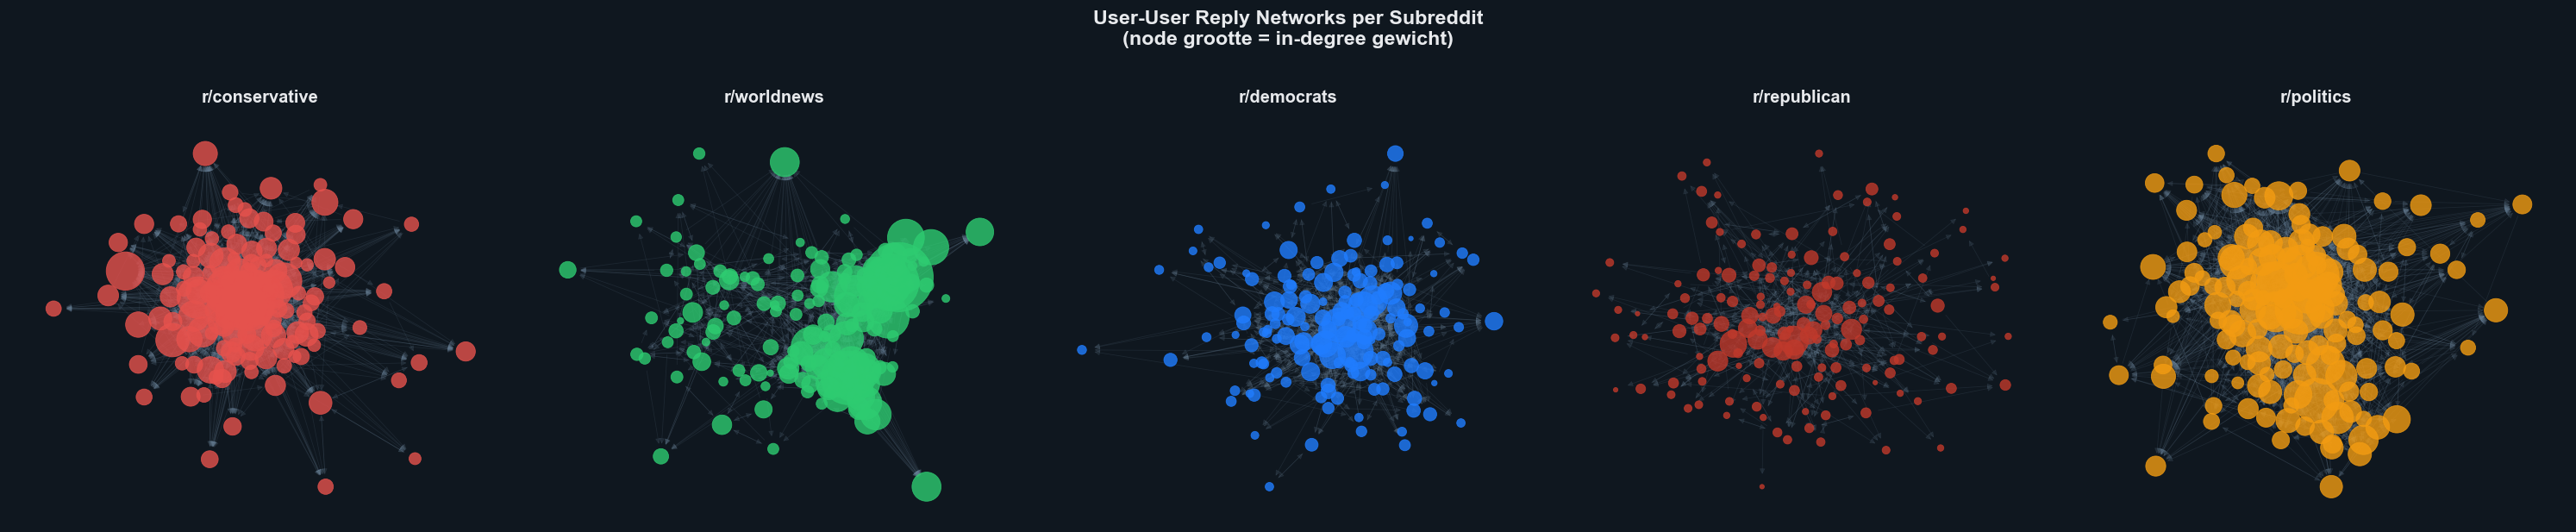

In [6]:
def plot_reply_network(G, title, color, ax):
    if G.number_of_nodes() == 0:
        ax.text(0.5, 0.5, 'No data', ha='center', va='center', color=TEXT_PRIMARY, transform=ax.transAxes)
        ax.set_title(title, color=TEXT_PRIMARY)
        return

    # Use only the largest weakly connected component for visualisation
    largest_cc = max(nx.weakly_connected_components(G), key=len)
    G_sub = G.subgraph(largest_cc).copy()

    # Limit to max 150 nodes for readability
    if len(G_sub) > 150:
        top_nodes = sorted(G_sub.in_degree(weight='weight'), key=lambda x: x[1], reverse=True)[:150]
        G_sub = G_sub.subgraph([n for n, _ in top_nodes]).copy()

    pos = nx.spring_layout(G_sub, seed=42, k=0.5)
    in_degrees = dict(G_sub.in_degree(weight='weight'))
    node_sizes = [max(10, in_degrees.get(n, 0) * 5) for n in G_sub.nodes()]

    nx.draw_networkx_nodes(G_sub, pos, ax=ax, node_size=node_sizes,
                           node_color=color, alpha=0.8)
    nx.draw_networkx_edges(G_sub, pos, ax=ax, alpha=0.15,
                           edge_color=TEXT_MUTED, arrows=True,
                           arrowsize=8, width=0.5)
    ax.set_title(title, color=TEXT_PRIMARY, fontsize=12)
    ax.axis('off')


subreddits = list(reply_graphs.keys())
n = len(subreddits)
fig, axes = plt.subplots(1, n, figsize=(5 * n, 5),
                         facecolor=BG_DARK)
for ax, sub in zip(axes, subreddits):
    ax.set_facecolor(BG_PANEL)
    plot_reply_network(reply_graphs[sub], f'r/{sub}',
                       SUBREDDIT_COLORS.get(sub, NEUTRAL), ax)

fig.suptitle('User-User Reply Networks per Subreddit\n(node grootte = in-degree gewicht)',
             color=TEXT_PRIMARY, fontsize=14, y=1.02)
plt.tight_layout()
plt.show()

---
## 2. Author Activity — Cross-subreddit Overlap

In [7]:
# Per author: how many subreddits active in?
author_subs = df.groupby('author')['subreddit'].apply(set).reset_index()
author_subs.columns = ['author', 'subreddits']
author_subs['n_subs'] = author_subs['subreddits'].apply(len)

print('Distribution: how many subreddits per author?')
print(author_subs['n_subs'].value_counts().sort_index())
cross_authors = author_subs[author_subs['n_subs'] > 1]
print(f'\nCross-subreddit authors: {len(cross_authors):,} ({len(cross_authors)/len(author_subs)*100:.1f}%)')

Verdeling: hoeveel subreddits per auteur?
n_subs
1    387264
2     74285
3     10108
4       692
5        20
Name: count, dtype: int64

Cross-subreddit auteurs: 85,105 (18.0%)


In [8]:
# Overlap heatmap: shared authors between each pair of subreddits
subs = sorted(df['subreddit'].unique())
overlap_matrix = pd.DataFrame(0, index=subs, columns=subs, dtype=int)

sub_to_authors = {s: set(df[df['subreddit'] == s]['author']) for s in subs}

for s1 in subs:
    for s2 in subs:
        overlap_matrix.loc[s1, s2] = len(sub_to_authors[s1] & sub_to_authors[s2])

print('Overlap matrix (shared authors):')
print(overlap_matrix)

Overlap matrix (gedeelde auteurs):
              conservative  democrats  politics  republican  worldnews
conservative         35866       1838     10058        1424       6143
democrats             1838      48582     17255         381      11250
politics             10058      17255    228650        1045      58957
republican            1424        381      1045        9955        610
worldnews             6143      11250     58957         610     245973


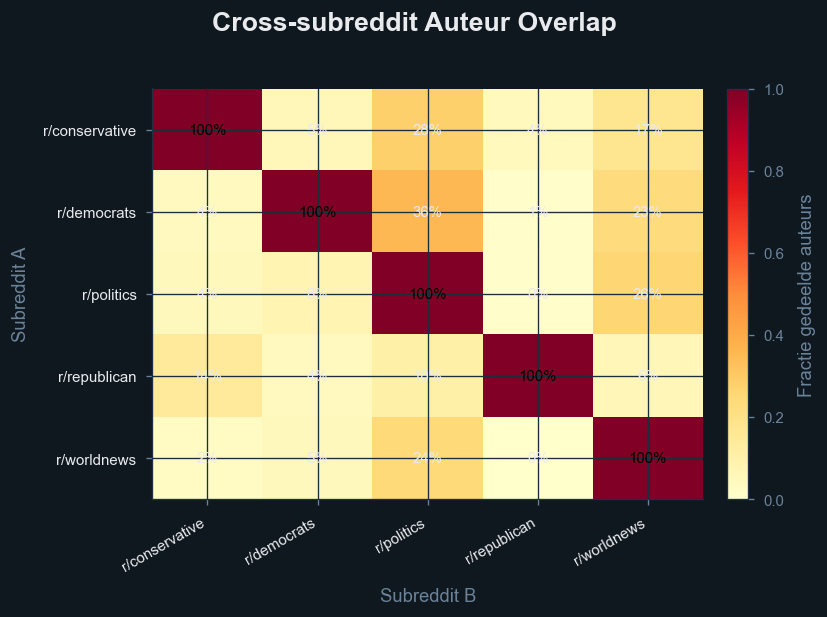

In [9]:
import matplotlib.colors as mcolors

fig, ax = styled_fig(figsize=(7, 5), title='Cross-subreddit Author Overlap')

# Normalise on diagonal (= total unique authors per subreddit)
diag = np.diag(overlap_matrix.values).astype(float)
norm_matrix = overlap_matrix.values / diag[:, None]  # row-normalised

im = ax.imshow(norm_matrix, cmap='YlOrRd', aspect='auto', vmin=0, vmax=1)
ax.set_xticks(range(len(subs)))
ax.set_yticks(range(len(subs)))
ax.set_xticklabels([f'r/{s}' for s in subs], rotation=30, ha='right', color=TEXT_PRIMARY)
ax.set_yticklabels([f'r/{s}' for s in subs], color=TEXT_PRIMARY)

# Annotate with percentages
for i in range(len(subs)):
    for j in range(len(subs)):
        ax.text(j, i, f'{norm_matrix[i, j]:.0%}',
                ha='center', va='center', fontsize=9,
                color='black' if norm_matrix[i, j] > 0.5 else TEXT_PRIMARY)

cbar = fig.colorbar(im, ax=ax, fraction=0.046, pad=0.04)
cbar.ax.yaxis.set_tick_params(color=TEXT_MUTED)
cbar.set_label('Fraction of shared authors', color=TEXT_MUTED)

ax.set_xlabel('Subreddit B', color=TEXT_MUTED)
ax.set_ylabel('Subreddit A', color=TEXT_MUTED)
plt.tight_layout()
plt.show()

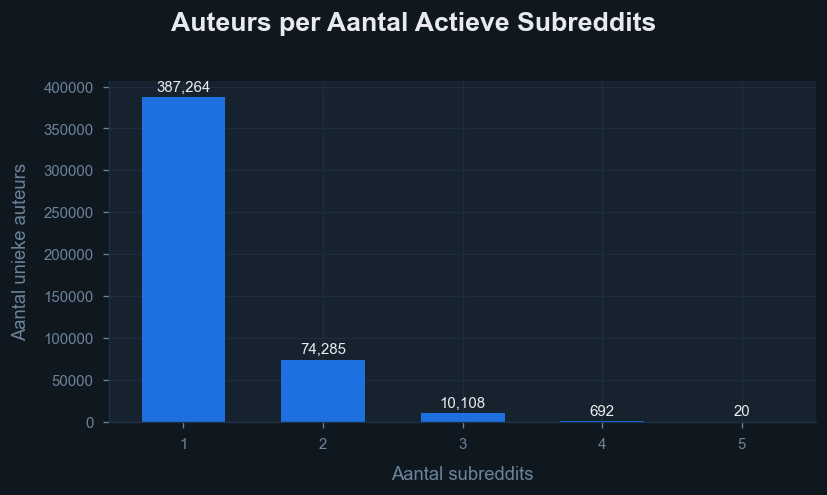

In [10]:
# Distribution: bar chart of authors active in 1, 2, 3, ... subreddits
fig, ax = styled_fig(figsize=(7, 4), title='Authors per Number of Active Subreddits')

counts = author_subs['n_subs'].value_counts().sort_index()
bars = ax.bar(counts.index, counts.values, color=DEMOCRAT, alpha=0.85, width=0.6)

for bar in bars:
    ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + counts.max() * 0.01,
            f'{bar.get_height():,}', ha='center', va='bottom', color=TEXT_PRIMARY, fontsize=9)

ax.set_xlabel('Number of subreddits', color=TEXT_MUTED)
ax.set_ylabel('Number of unique authors', color=TEXT_MUTED)
ax.set_xticks(counts.index)
plt.tight_layout()
plt.show()

---
## 3. Post-Comment Bipartite Network — Engagement

In [11]:
# Link comments to posts via link_id (t3_XXX → post id = XXX)
df['post_id'] = df['link_id'].str.replace('^t3_', '', regex=True)

# Number of comments per post
comment_counts = df.groupby(['subreddit', 'post_id']).size().reset_index(name='n_comments')
comment_counts_joined = comment_counts.merge(
    df_posts[['id', 'title', 'score', 'upvote_ratio', 'subreddit']].rename(columns={'id': 'post_id', 'subreddit': 'sub_post'}),
    on='post_id', how='left'
)

print('Top 10 most commented posts:')
print(comment_counts_joined.sort_values('n_comments', ascending=False)
      [['subreddit', 'title', 'n_comments', 'score']].head(10).to_string(index=False))

Top 10 meest becommentarieerde posts:
subreddit                                                                                      title  n_comments   score
 politics       Megathread: Shots Fired at Trump Rally, Former President Evacuated by Secret Service       31431 33027.0
 politics                     Megathread: President Biden Announces That He Will Not Seek Reelection       26181 55882.0
 politics                Megathread: Trump Safe After Gunfire at Rally, Reports Say Shooter Deceased       16939  5918.0
 politics                   Discussion Thread: President Biden Gives Press Conference at NATO Summit       15478  5944.0
 politics                                        /r/Politics' 2024 US Elections Live Thread, Part 10       13361    62.0
 politics                              Discussion Thread: 2024 Republican National Convention, Day 4       13355    67.0
 politics                                        /r/Politics' 2024 US Elections Live Thread, Part 11       13303   

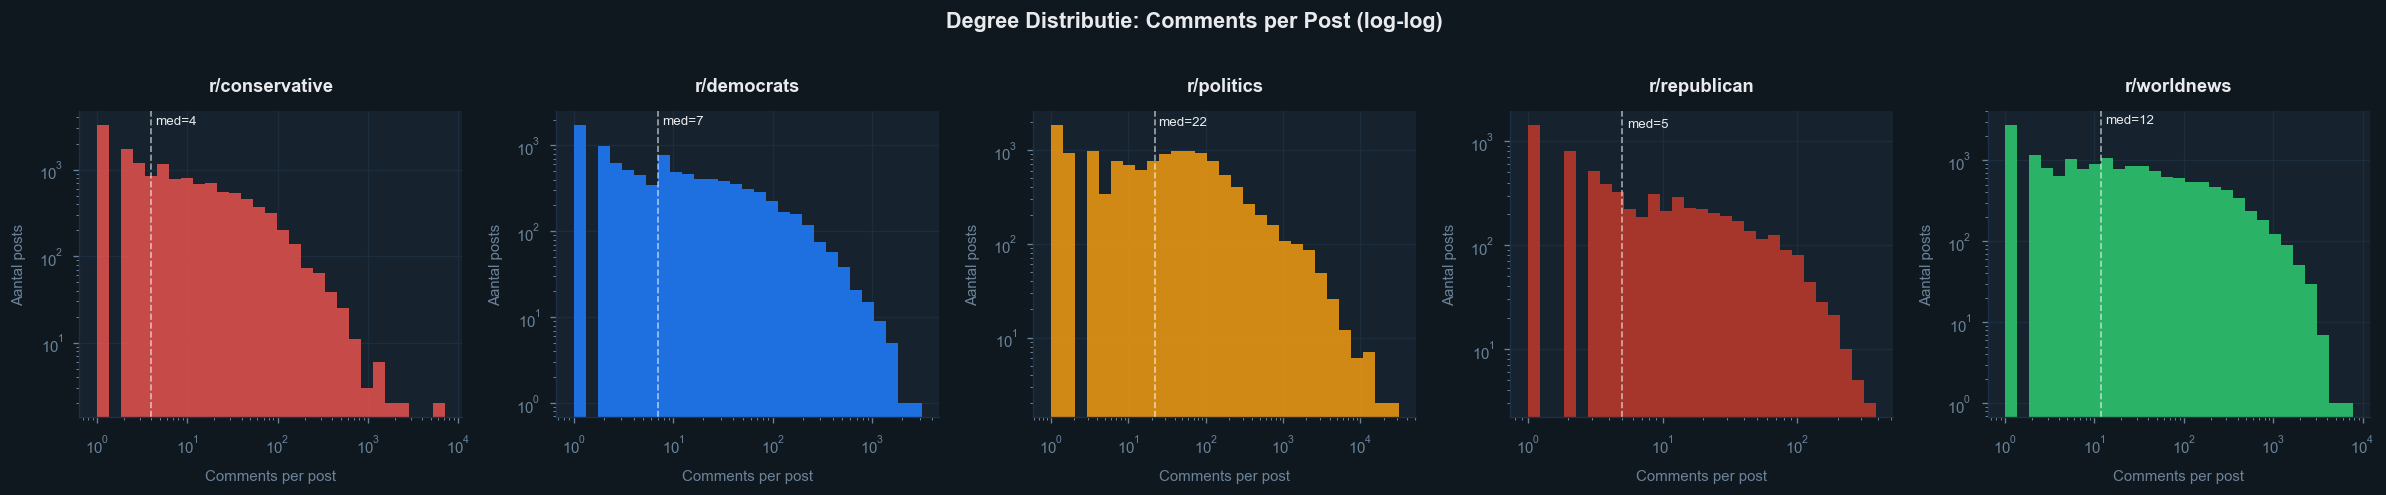

In [12]:
# Degree distribution: how many comments does the average post get?
fig, axes = plt.subplots(1, len(subs), figsize=(4 * len(subs), 4),
                          facecolor=BG_DARK, sharey=False)

for ax, sub in zip(axes, subs):
    ax.set_facecolor(BG_PANEL)
    sub_data = comment_counts[comment_counts['subreddit'] == sub]['n_comments']
    if len(sub_data) == 0:
        continue
    # Log-binned histogram
    bins = np.logspace(0, np.log10(sub_data.max() + 1), 30)
    ax.hist(sub_data, bins=bins, color=SUBREDDIT_COLORS.get(sub, NEUTRAL),
            alpha=0.85, edgecolor='none')
    ax.set_xscale('log')
    ax.set_yscale('log')
    ax.set_title(f'r/{sub}', color=TEXT_PRIMARY, fontsize=11)
    ax.set_xlabel('Comments per post', color=TEXT_MUTED, fontsize=9)
    ax.set_ylabel('Number of posts', color=TEXT_MUTED, fontsize=9)
    ax.tick_params(colors=TEXT_MUTED)
    median = sub_data.median()
    ax.axvline(median, color='white', linewidth=1, linestyle='--', alpha=0.6)
    ax.text(median * 1.1, ax.get_ylim()[1] * 0.7, f'med={median:.0f}',
            color=TEXT_PRIMARY, fontsize=8)

fig.suptitle('Degree Distributie: Comments per Post (log-log)',
             color=TEXT_PRIMARY, fontsize=13, y=1.02)
plt.tight_layout()
plt.show()

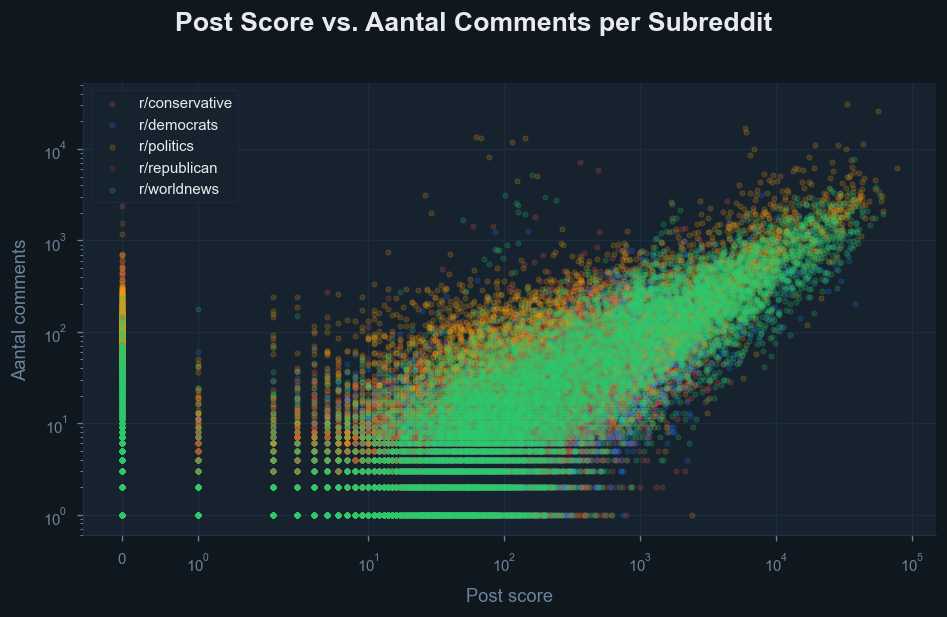

In [13]:
# Score vs. engagement per subreddit (scatter)
fig, ax = styled_fig(figsize=(8, 5), title='Post Score vs. Number of Comments per Subreddit')

for sub in subs:
    sub_df = comment_counts_joined[comment_counts_joined['subreddit'] == sub].dropna(subset=['score'])
    if len(sub_df) == 0:
        continue
    ax.scatter(sub_df['score'], sub_df['n_comments'],
               alpha=0.2, s=10, label=f'r/{sub}',
               color=SUBREDDIT_COLORS.get(sub, NEUTRAL))

ax.set_xscale('symlog')
ax.set_yscale('log')
ax.set_xlabel('Post score', color=TEXT_MUTED)
ax.set_ylabel('Number of comments', color=TEXT_MUTED)
ax.legend(facecolor=BG_PANEL, labelcolor=TEXT_PRIMARY, framealpha=0.8)
plt.tight_layout()
plt.show()